In [1]:
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sbi.inference import NPE, simulate_for_sbi
from sbi.utils import BoxUniform
from sbi.analysis import pairplot
import matplotlib.pyplot as plt

print("Démarrage de Julia et chargement du modèle...")
from juliacall import Main as jl
jl.include("passerelle.jl")
print("Pont Python-Julia établi !")

# --- LA NOUVELLE FONCTION AVEC MOYENNE (SWEEPS) ---
def simulateur_sbi_hybride(theta):
    theta = torch.atleast_2d(theta)
    resultats_simules = []
    
    # Nombre de stimulations à moyenner (comme in vitro)
    N_SWEEPS = 10 

    for jeu_de_parametres in theta:
        val_ampa = float(jeu_de_parametres[0])
        val_nmda = float(jeu_de_parametres[1])
        
        sweeps_combines = []
        
        # On lance N fois la simulation avec les mêmes paramètres
        for _ in range(N_SWEEPS):
            t_julia, v_julia, ca_julia = jl.simuler_synapse_brute(val_ampa, val_nmda)
            
            # Interpolation sur 500 points
            t_fixe = np.linspace(float(t_julia[0]), float(t_julia[-1]), 500)
            v_fixe = np.interp(t_fixe, list(t_julia), list(v_julia))
            ca_fixe = np.interp(t_fixe, list(t_julia), list(ca_julia))
            
            # On combine Vsp et Ca
            courbe_combinee = np.concatenate([v_fixe, ca_fixe])
            sweeps_combines.append(courbe_combinee)
            
        # NOUVEAU : On fait la moyenne mathématique des 10 courbes
        courbe_moyenne = np.mean(sweeps_combines, axis=0)
        
        # On donne la courbe moyennée à PyTorch
        courbe_pytorch = torch.tensor(courbe_moyenne, dtype=torch.float32)
        resultats_simules.append(courbe_pytorch)
        
    return torch.stack(resultats_simules)

Démarrage de Julia et chargement du modèle...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating new project at `~/derryInternship/SynapseElife.jl/sbi`
[ Info: Precompiling SciMLBasePythonCallExt [2797fd30-2078-5027-980c-4c2c8a19c528]
Precompiling packages...
Info Given SciMLBasePythonCallExt was explicitly requested, output will be shown live 
ERROR: LoadError: ArgumentError: Package PythonCall [6099a3de-0909-46bc-b1f4-468b9a2dfc0d] is required but does not seem to be installed:
 - Run `Pkg.instantiate()` to install all recorded dependencies.

Stacktrace:
  [1] __require_prelocked(pkg::Base.PkgId, env::String)
    @ Base ./loading.jl:2617
  [2] _require_prelocked(uuidkey::Base.PkgId, env::String)
    @ Base ./loading.jl:2495
  [3] macro expansion
    @ ./loading.jl:2423 [inlined]
  [4] macro expansion
    @ ./lock.jl:376 [inlined]
  [5] __require(into::Module, mod::Symbol)
    @ Base ./loading.jl:2388
  [6] require(into::Module, mod::Symbol)
    @ Base ./loading.jl:2364
  [7] top-level scope
    @ ~/.julia/packages/SciMLBase/O1HPI/ext/SciMLBasePythonCallExt.jl:3
  [8

Pont Python-Julia établi !


In [2]:
# --- LE PRIOR ET L'ENTRAÎNEMENT ---
prior = BoxUniform(
    low=torch.tensor([0.001, 0.001]), 
    high=torch.tensor([0.1, 0.1])
)

print("\nLancement des simulations par l'IA...")
# ATTENTION : 200 simulations * 10 sweeps = 2000 calculs Julia !
# J'ai réduit à 200 pour que le test ne prenne pas toute l'après-midi.
theta_sim, x_sim = simulate_for_sbi(simulateur_sbi_hybride, prior, num_simulations=200)

print("Entraînement du réseau de neurones...")
inference = NPE(prior)
inference.append_simulations(theta_sim, x_sim)
inference.train(show_train_summary=False)
posterior = inference.build_posterior()





Lancement des simulations par l'IA...


  0%|          | 0/200 [00:00<?, ?it/s]

  0.136817 seconds (762.30 k allocations: 26.733 MiB)
  0.140165 seconds (772.58 k allocations: 26.941 MiB)
  0.127445 seconds (719.94 k allocations: 25.320 MiB)
  0.188434 seconds (702.73 k allocations: 24.235 MiB, 26.42% gc time)
  0.133879 seconds (732.12 k allocations: 25.221 MiB)
  0.130734 seconds (722.11 k allocations: 25.115 MiB)
  0.134707 seconds (736.47 k allocations: 25.485 MiB)
  0.128292 seconds (721.38 k allocations: 25.318 MiB)


  0%|          | 1/200 [00:25<1:24:16, 25.41s/it]

  0.118599 seconds (659.20 k allocations: 22.883 MiB)
  0.133413 seconds (737.27 k allocations: 25.400 MiB)
  0.151131 seconds (830.14 k allocations: 27.997 MiB)
  0.181642 seconds (941.35 k allocations: 31.225 MiB)
  0.129105 seconds (684.27 k allocations: 23.462 MiB)
  0.168226 seconds (789.85 k allocations: 26.637 MiB)
  0.134557 seconds (739.94 k allocations: 25.102 MiB)
  0.139075 seconds (719.09 k allocations: 24.384 MiB)
  0.158010 seconds (854.87 k allocations: 28.524 MiB)
  0.123705 seconds (658.44 k allocations: 22.378 MiB)


...

100%|█████████▉| 199/200 [15:07<00:04,  4.52s/it]

  0.142897 seconds (788.99 k allocations: 26.600 MiB)
  0.168228 seconds (880.92 k allocations: 29.332 MiB)
  0.183114 seconds (862.88 k allocations: 29.077 MiB)
  0.137226 seconds (704.76 k allocations: 24.253 MiB)
  0.141757 seconds (751.36 k allocations: 25.313 MiB)
  0.216583 seconds (883.14 k allocations: 29.452 MiB, 17.58% gc time)
  0.141753 seconds (775.34 k allocations: 26.282 MiB)
  0.130479 seconds (721.90 k allocations: 24.677 MiB)
  0.137062 seconds (745.59 k allocations: 25.674 MiB)
  0.166546 seconds (917.63 k allocations: 30.584 MiB)


100%|██████████| 200/200 [15:12<00:00,  4.56s/it]

  0.164183 seconds (831.66 k allocations: 27.805 MiB)
  0.135015 seconds (729.32 k allocations: 24.682 MiB)
Entraînement du réseau de neurones...


 Neural network successfully converged after 51 epochs.


--- TEST SCIENTIFIQUE (MOYENNE DE 10 SWEEPS) ---
Génération de l'expérience secrète (AMPA=0.08, NMDA=0.02)...
  0.129628 seconds (721.99 k allocations: 24.793 MiB)
  0.157008 seconds (833.00 k allocations: 28.076 MiB)
  0.148793 seconds (756.86 k allocations: 25.622 MiB)
  0.135129 seconds (747.20 k allocations: 25.638 MiB)
  0.144745 seconds (789.94 k allocations: 26.940 MiB)
  0.187175 seconds (928.63 k allocations: 31.154 MiB)
  0.153618 seconds (837.33 k allocations: 28.178 MiB)
  0.132139 seconds (751.41 k allocations: 25.443 MiB)
  0.186251 seconds (786.98 k allocations: 26.886 MiB, 18.43% gc time)
  0.132572 seconds (735.53 k allocations: 25.150 MiB)
L'IA tente de retrouver les valeurs secrètes...


11737it [00:00, 43911.99it/s]                          


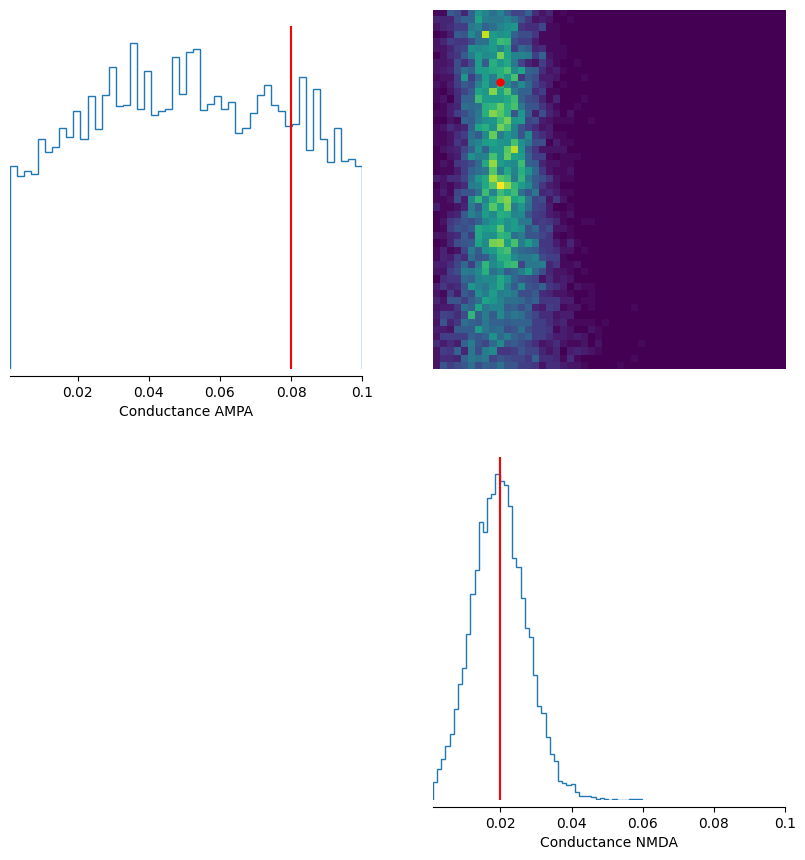

In [6]:
# --- LE NOUVEAU TEST CIBLE (AVEC MOYENNE AUSSI) ---
print("\n--- TEST SCIENTIFIQUE (MOYENNE DE 10 SWEEPS) ---")
vrai_ampa = 0.08
vrai_nmda = 0.02
print(f"Génération de l'expérience secrète (AMPA={vrai_ampa}, NMDA={vrai_nmda})...")

# On doit aussi moyenner la courbe cible pour que l'IA puisse comparer
sweeps_cible = []
for _ in range(10):
    t_cible, v_cible, ca_cible = jl.simuler_synapse_brute(vrai_ampa, vrai_nmda)
    t_fixe = np.linspace(float(t_cible[0]), float(t_cible[-1]), 500)
    v_fixe = np.interp(t_fixe, list(t_cible), list(v_cible))
    ca_fixe = np.interp(t_fixe, list(t_cible), list(ca_cible))
    sweeps_cible.append(np.concatenate([v_fixe, ca_fixe]))

courbe_cible_moyenne = torch.tensor(np.mean(sweeps_cible, axis=0), dtype=torch.float32)

print("L'IA tente de retrouver les valeurs secrètes...")
echantillons_devines = posterior.sample((10000,), x=courbe_cible_moyenne)

fig, axes = pairplot(
    echantillons_devines,
    limits=[[0.001, 0.1], [0.001, 0.1]], 
    labels=["Conductance AMPA", "Conductance NMDA"],
    points=[[vrai_ampa, vrai_nmda]], 
    points_colors=["red"]
)
plt.show()